# **KELOMPOK 4**
* Gracya Nurmala Sinurat 		(09011282227077)
* Alyssa Khairunisa Maharani 		(09011282227119)
* Fauziah Rachel Audrey Chealsea	(09011382227152)
* M. A. Tanjung Idrussalam		(09011282227107)
* M. Alfath Sudarja			(09011282227029)

In [1]:
import os
import random
import itertools
from collections import defaultdict
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from skimage.measure import shannon_entropy
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from tqdm import tqdm

# Set seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_path = '/content/drive/MyDrive/cimed/segmen'

# AUTO-DETECT CATEGORY DARI FOLDER
CATEGORIES = [
    d for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))
]

print("Category ditemukan:", CATEGORIES)
LABEL_MAP = {'milky': 0, 'opaque': 1, 'transparent': 2}
CIN_MAP = {
    0: "CIN 3 (High Risk)",
    1: "CIN 2 (Moderate Risk)",
    2: "CIN 1 / Normal (Low Risk)"
}

Category ditemukan: ['train', 'test']


In [5]:
def show_directory_tree(path):
    print(f" Root Directory: {path}\n")
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent} {os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files[:5]:  # batasi biar nggak kepanjangan
            print(f"{subindent} {f}")

show_directory_tree(base_path)


 Root Directory: /content/drive/MyDrive/cimed/segmen

 segmen/
     train/
         transparent/
             Case 188/
                 AAGO3.jpg
                 AAGO4.jpg
             Case 191/
                 AAAO4.jpg
             Case 187/
                 AAEX1.jpg
             Case 176/
                 AAEL3.jpg
             Case 173/
                 AADM5.jpg
             Case 096/
                 AAEJ1.jpg
             Case 080/
                 AAJL3.jpg
             Case 085/
                 AACK4.jpg
             Case 088/
                 AAJB2.jpg
             Case 070/
                 AAAV0.jpg
             Case 069/
                 AAAU2.jpg
             Case 071/
                 AAGZ3.jpg
             Case 079/
                 AAHK4.jpg
                 AAHK3.jpg
                 AAHK2.jpg
             Case 068/
                 AAAT3.jpg
             Case 062/
                 AAII2.jpg
                 AAII3.jpg
             Case 067/
                 AAFI2

# **TAMPILKAN CONTOH GAMBAR PER KATEGORI**

In [6]:
def get_all_images_from_category(category_path):
    image_paths = []

    for root, _, files in os.walk(category_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))

    return image_paths

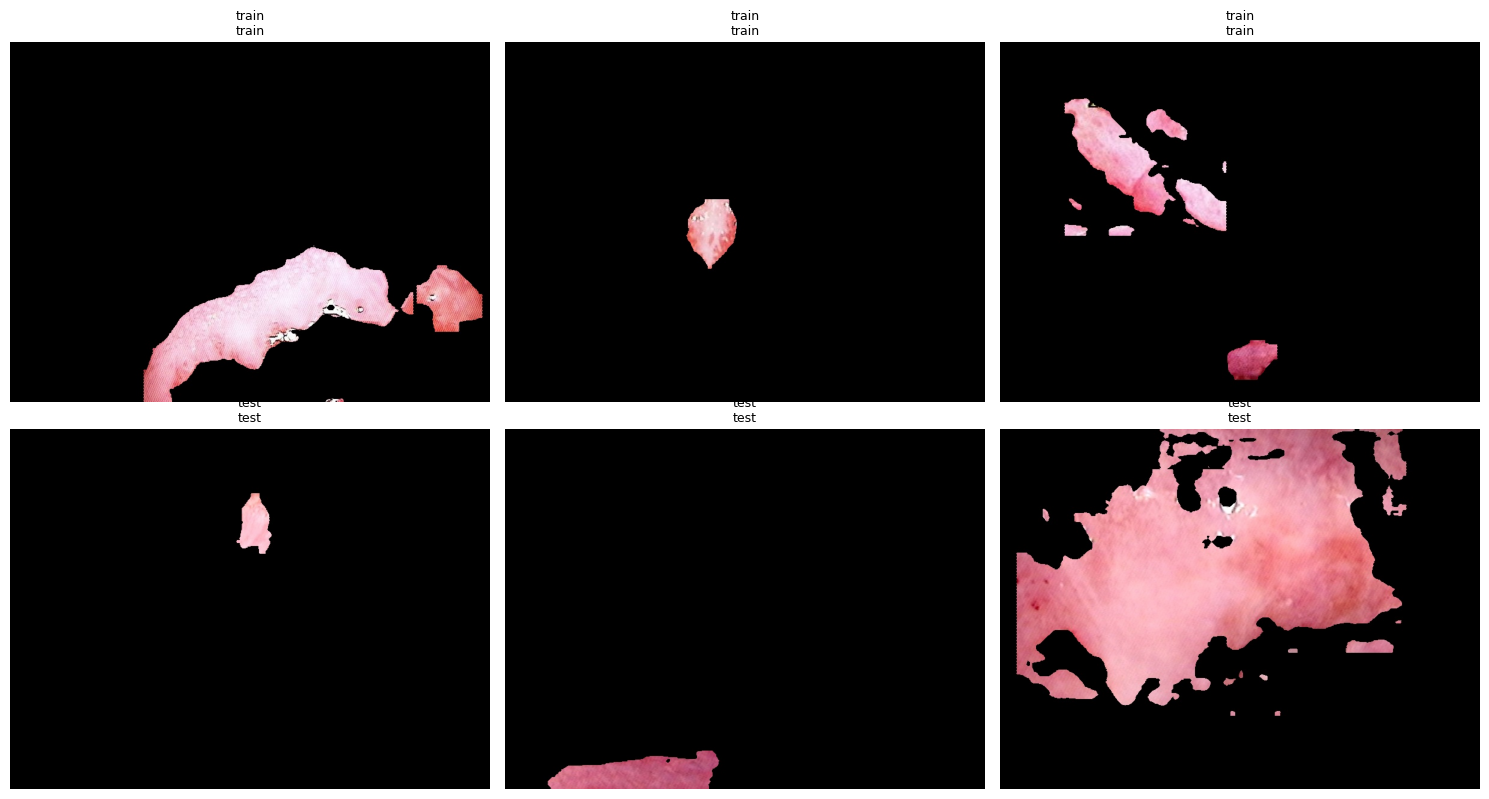

In [7]:
def show_sample_images(base_path, categories, samples_per_class=3):
    total_plots = len(categories) * samples_per_class
    plt.figure(figsize=(5 * samples_per_class, 4 * len(categories)))

    img_count = 1

    for category in categories:
        category_path = os.path.join(base_path, category)
        images = get_all_images_from_category(category_path)

        if len(images) == 0:
            print(f" Tidak ada gambar di {category}")
            continue

        samples = random.sample(images, min(samples_per_class, len(images)))

        for img_path in samples:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(categories), samples_per_class, img_count)
            plt.imshow(img)
            plt.axis('off')

            label_text = CIN_MAP[LABEL_MAP[category]] if category in LABEL_MAP else category
            plt.title(f"{category}\n{label_text}", fontsize=9)

            img_count += 1

    plt.tight_layout()
    plt.show()


#  JALANKAN
show_sample_images(base_path, CATEGORIES, samples_per_class=3)

# **WHITE BALANCE**

In [8]:
def apply_white_balance(img_bgr):
    """Gray-world white balance untuk normalisasi warna."""
    img = img_bgr.astype(np.float32)

    avg_b = np.mean(img[:, :, 0])
    avg_g = np.mean(img[:, :, 1])
    avg_r = np.mean(img[:, :, 2])
    avg_gray = (avg_b + avg_g + avg_r) / 3.0

    # Hindari division by zero
    avg_b = max(avg_b, 1)
    avg_g = max(avg_g, 1)
    avg_r = max(avg_r, 1)

    img[:, :, 0] *= (avg_gray / avg_b)
    img[:, :, 1] *= (avg_gray / avg_g)
    img[:, :, 2] *= (avg_gray / avg_r)

    return np.clip(img, 0, 255).astype(np.uint8)

In [9]:
def show_before_after_white_balance(image_path):
    """
    Menampilkan gambar sebelum dan sesudah white balance.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Gagal membaca gambar:", image_path)
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    wb_bgr = apply_white_balance(img_bgr)
    wb_rgb = cv2.cvtColor(wb_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Sebelum White Balance")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(wb_rgb)
    plt.title("Sesudah White Balance")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Menggunakan sample MILKY pertama untuk display manual: /content/drive/MyDrive/cimed/segmen/train/milky/Case 183/AADS5.jpg


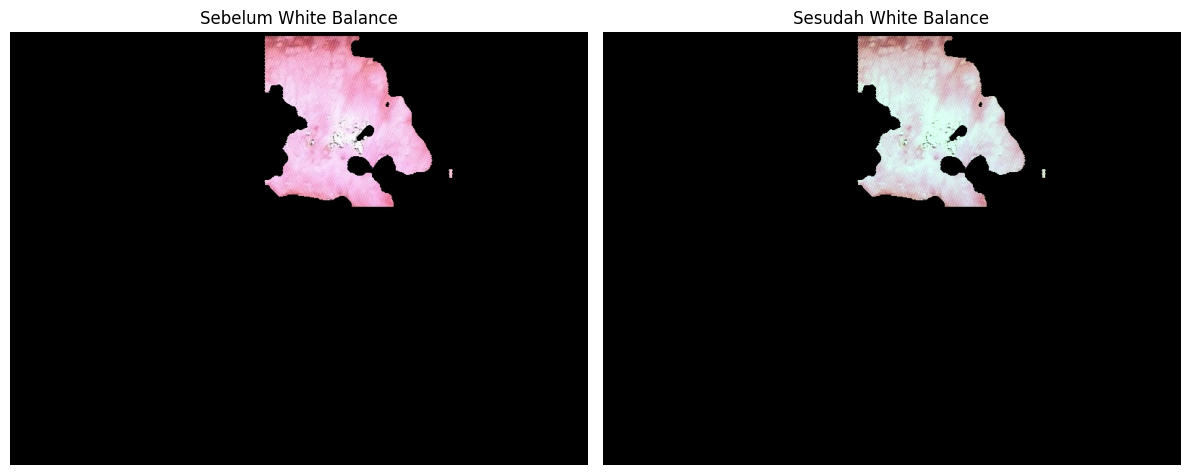

Sample MILKY (kedua): /content/drive/MyDrive/cimed/segmen/train/milky/Case 183/AADS5.jpg


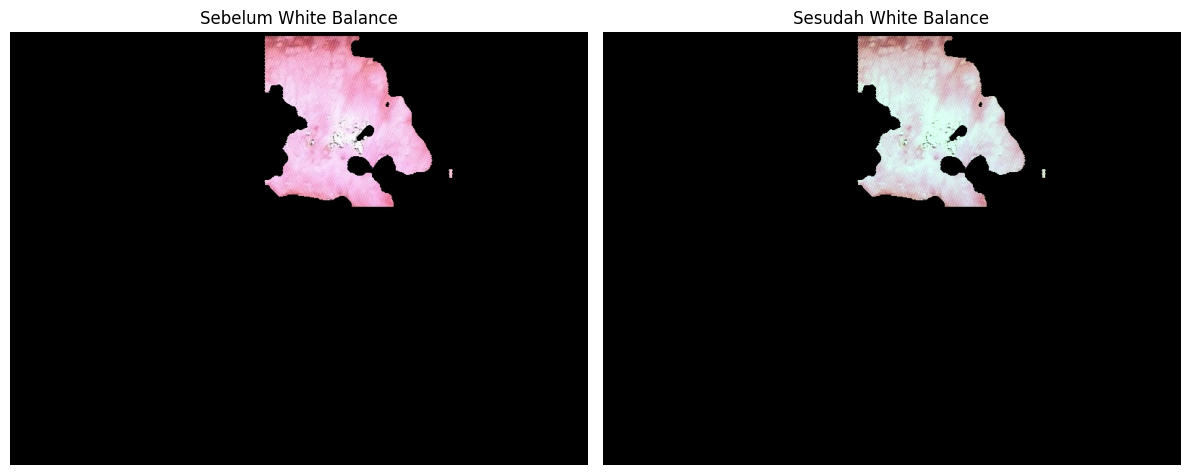

In [10]:
CATEGORIES_FOR_THIS_CELL = ['milky', 'opaque', 'transparent']

categories_images = defaultdict(list)

# Populate categories_images dictionary by iterating through splits and categories
for split in ['train', 'test']:
    for category in CATEGORIES_FOR_THIS_CELL:
        # Construct the path to the current category within the split
        category_split_path = os.path.join(base_path, split, category)
        if os.path.exists(category_split_path) and os.path.isdir(category_split_path):
            # Use the previously defined get_all_images_from_category function
            images_in_category = get_all_images_from_category(category_split_path)
            categories_images[category].extend(images_in_category)

# The original 'sample_manual' was a directory path, causing "Gagal membaca gambar"
# Now, we use an actual image path from the collected categories_images
sample_manual_path = None
if 'milky' in categories_images and len(categories_images['milky']) > 0:
    sample_manual_path = categories_images['milky'][0]
    print(f"Menggunakan sample MILKY pertama untuk display manual: {sample_manual_path}")
    show_before_after_white_balance(sample_manual_path)
else:
    print("Tidak ada gambar 'milky' ditemukan untuk tampilan white balance.")

# This part was the direct cause of NameError for categories_images
if 'milky' in categories_images and len(categories_images['milky']) > 0:
    sample_path = categories_images['milky'][0]
    print(f"Sample MILKY (kedua): {sample_path}")
    show_before_after_white_balance(sample_path)
else:
    print("Tidak ada gambar 'milky' ditemukan untuk tampilan white balance.")

## **AUGMENTASI MILKY**

In [11]:
def augment_image_and_mask(img, mask):
    """
    Augmentasi dengan:
    - Flip Horizontal (kiri ↔ kanan)
    - Flip Vertical (atas ↕ bawah)
    - Rotasi 90°, 180°, 270°
    """
    augmented_imgs = []
    augmented_masks = []

    # Flip Horizontal
    augmented_imgs.append(cv2.flip(img, 1))
    augmented_masks.append(cv2.flip(mask, 1))

    # Flip Vertical
    augmented_imgs.append(cv2.flip(img, 0))
    augmented_masks.append(cv2.flip(mask, 0))

    # Rotasi 90 derajat (clockwise)
    augmented_imgs.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    augmented_masks.append(cv2.rotate(mask, cv2.ROTATE_90_CLOCKWISE))

    return augmented_imgs, augmented_masks

In [12]:
def count_images(folder):
    total = 0
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                total += 1
    return total

before = defaultdict(dict)

splits = ['train', 'test']
actual_categories = ['milky', 'opaque', 'transparent'] # Use the correct categories

for split in splits:
    for cls in actual_categories:
        cls_path = os.path.join(base_path, split, cls)
        before[split][cls] = count_images(cls_path) if os.path.exists(cls_path) else 0

print(" JUMLAH DATASET SEBELUM AUGMENTASI\n")
total_before = 0
for split in splits:
    print(f"[{split.upper()}]")
    for cls in actual_categories:
        print(f"  {cls:12s}: {before[split][cls]}")
        total_before += before[split][cls]

print(f"\n TOTAL SEBELUM AUGMENTASI: {total_before}")

 JUMLAH DATASET SEBELUM AUGMENTASI

[TRAIN]
  milky       : 31
  opaque      : 85
  transparent : 54
[TEST]
  milky       : 6
  opaque      : 22
  transparent : 19

 TOTAL SEBELUM AUGMENTASI: 217


In [13]:
AUGMENT_FACTOR = 3

after = defaultdict(dict)

print("\n" + "="*40)
print(" STATISTIK DATASET (AUGMENTASI KHUSUS MILKY)")
print("="*40)

for split in splits:
    for cls in actual_categories:
        # Terapkan augmentasi HANYA jika folder TRAIN dan kelasnya 'milky'
        if split == 'train' and cls == 'milky':
            after[split][cls] = before[split][cls] * AUGMENT_FACTOR
        else:
            # Data TEST dan kelas lain (opaque, transparent) di TRAIN tidak diaugmentasi
            after[split][cls] = before[split][cls]

total_after = 0
for split in splits:
    print(f"[{split.upper()}]")
    for cls in actual_categories:
        print(f"  {cls:12s}: {after[split][cls]}")
        total_after += after[split][cls]

print(f"\n TOTAL SETELAH AUGMENTASI: {total_after}")


 STATISTIK DATASET (AUGMENTASI KHUSUS MILKY)
[TRAIN]
  milky       : 93
  opaque      : 85
  transparent : 54
[TEST]
  milky       : 6
  opaque      : 22
  transparent : 19

 TOTAL SETELAH AUGMENTASI: 279


# CieLAB

In [14]:
def _extract_image_features(image_rgb, mask):

    try:
        binary_mask = mask > 0

        if np.sum(binary_mask) < 10:
            return None

        features = {}

        img_lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        L, a, b = cv2.split(img_lab)

        L_pixels = L[binary_mask].astype(np.float64)
        a_pixels = a[binary_mask].astype(np.float64)
        b_pixels = b[binary_mask].astype(np.float64)

        features['L_mean'] = np.mean(L_pixels)
        features['a_mean'] = np.mean(a_pixels)
        features['b_mean'] = np.mean(b_pixels)

        features['L_std'] = np.std(L_pixels, ddof=1)
        features['a_std'] = np.std(a_pixels, ddof=1)
        features['b_std'] = np.std(b_pixels, ddof=1)


        #  CHROMA - Extended
        chroma = np.sqrt((a_pixels - 128)**2 + (b_pixels - 128)**2)
        features['Chroma_mean'] = np.mean(chroma)
        features['Chroma_std'] = np.std(chroma, ddof=1)
        features['Chroma_max'] = np.max(chroma)
        features['Chroma_min'] = np.min(chroma)

        #  HUE ANGLE
        hue_angle = np.arctan2(b_pixels - 128, a_pixels - 128)
        features['Hue_mean'] = np.mean(hue_angle)
        features['Hue_std'] = np.std(hue_angle, ddof=1)
        features['Hue_circular_mean'] = np.arctan2(
            np.mean(np.sin(hue_angle)),
            np.mean(np.cos(hue_angle))
        )
        features['Hue_concentration'] = np.sqrt(
            np.mean(np.cos(hue_angle))**2 + np.mean(np.sin(hue_angle))**2
        )

        #  COLOR DOMINANCE
        # Lightness dominance (high L* = terang)
        features['Light_dominance'] = np.sum(L_pixels > 128) / len(L_pixels)

        # Redness dominance (positive a* = red)
        features['Red_dominance'] = np.sum(a_pixels > 128) / len(a_pixels)

        # Yellowness dominance (positive b* = yellow)
        features['Yellow_dominance'] = np.sum(b_pixels > 128) / len(b_pixels)

        # PERCENTILES
        features['L_p25'] = np.percentile(L_pixels, 25)
        features['L_p50'] = np.percentile(L_pixels, 50)
        features['L_p75'] = np.percentile(L_pixels, 75)

        features['a_p25'] = np.percentile(a_pixels, 25)
        features['a_p50'] = np.percentile(a_pixels, 50)
        features['a_p75'] = np.percentile(a_pixels, 75)

        features['b_p25'] = np.percentile(b_pixels, 25)
        features['b_p50'] = np.percentile(b_pixels, 50)
        features['b_p75'] = np.percentile(b_pixels, 75)

        # COLOR CONTRAST
        features['Lab_contrast'] = np.std(L_pixels, ddof=1) / (np.mean(L_pixels) + 1e-7)
        features['Chroma_contrast'] = np.std(chroma, ddof=1) / (np.mean(chroma) + 1e-7)
        features['ab_distance'] = np.sqrt(
            np.mean((a_pixels - np.mean(a_pixels))**2 +
                   (b_pixels - np.mean(b_pixels))**2)
        )

        return features

    except Exception as e:
        print(f"Error extracting features: {e}")
        return None

In [15]:
# Visualisasi
def visualize_cielab(image_path, category_name):

    image = cv2.imread(image_path)
    if image is None: return

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(image_lab)

    l_masked = np.ma.masked_where(mask == 0, l)
    a_masked = np.ma.masked_where(mask == 0, a)
    b_masked = np.ma.masked_where(mask == 0, b)

    cmap_l = plt.get_cmap('gray').copy()
    cmap_l.set_bad(color='black')

    cmap_a = plt.get_cmap('RdYlGn_r').copy()
    cmap_a.set_bad(color='black')

    cmap_b = plt.get_cmap('RdYlBu_r').copy()
    cmap_b.set_bad(color='black')

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    plt.suptitle(f"Analisis Warna CIELAB: {category_name.upper()}", fontsize=20, fontweight='bold')

    axes[0].imshow(image_rgb); axes[0].set_title("Original"); axes[0].axis('off')

    im1 = axes[1].imshow(l_masked, cmap=cmap_l); axes[1].set_title("L"); axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(a_masked, cmap=cmap_a); axes[2].set_title("A"); axes[2].axis('off')
    fig.colorbar(im2, ax=axes[2])

    im3 = axes[3].imshow(b_masked, cmap=cmap_b); axes[3].set_title("B"); axes[3].axis('off')
    fig.colorbar(im3, ax=axes[3])

    plt.tight_layout()
    plt.show()


 Sample image: /content/drive/MyDrive/cimed/segmen/train/milky/Case 186/AAEW1.jpg


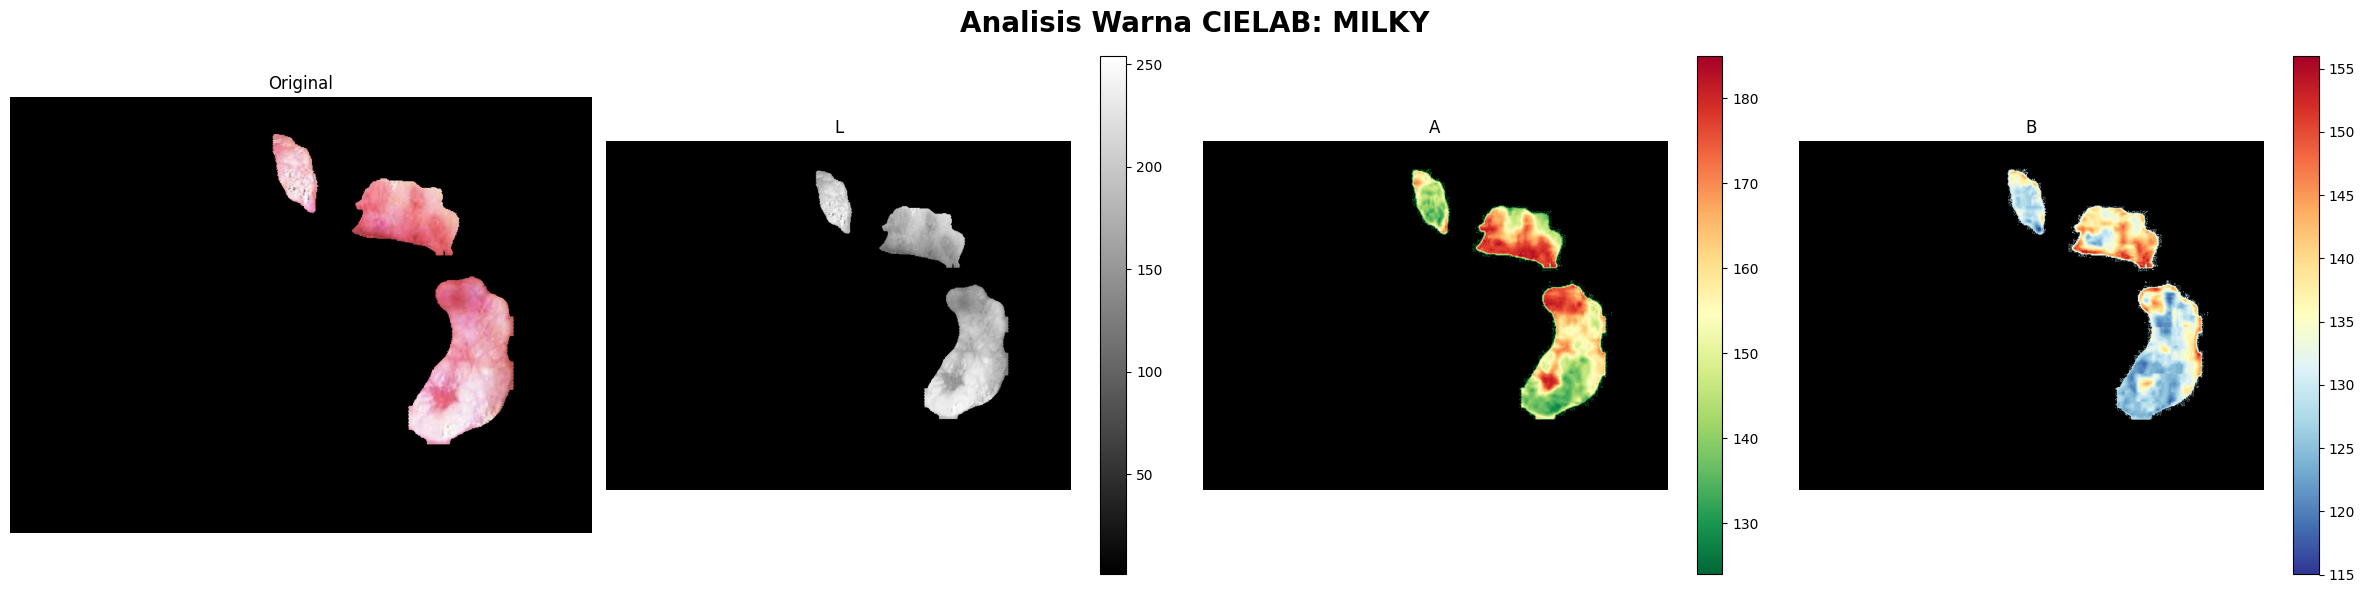

 Sample image: /content/drive/MyDrive/cimed/segmen/train/opaque/Case 167/AAAI05.jpg


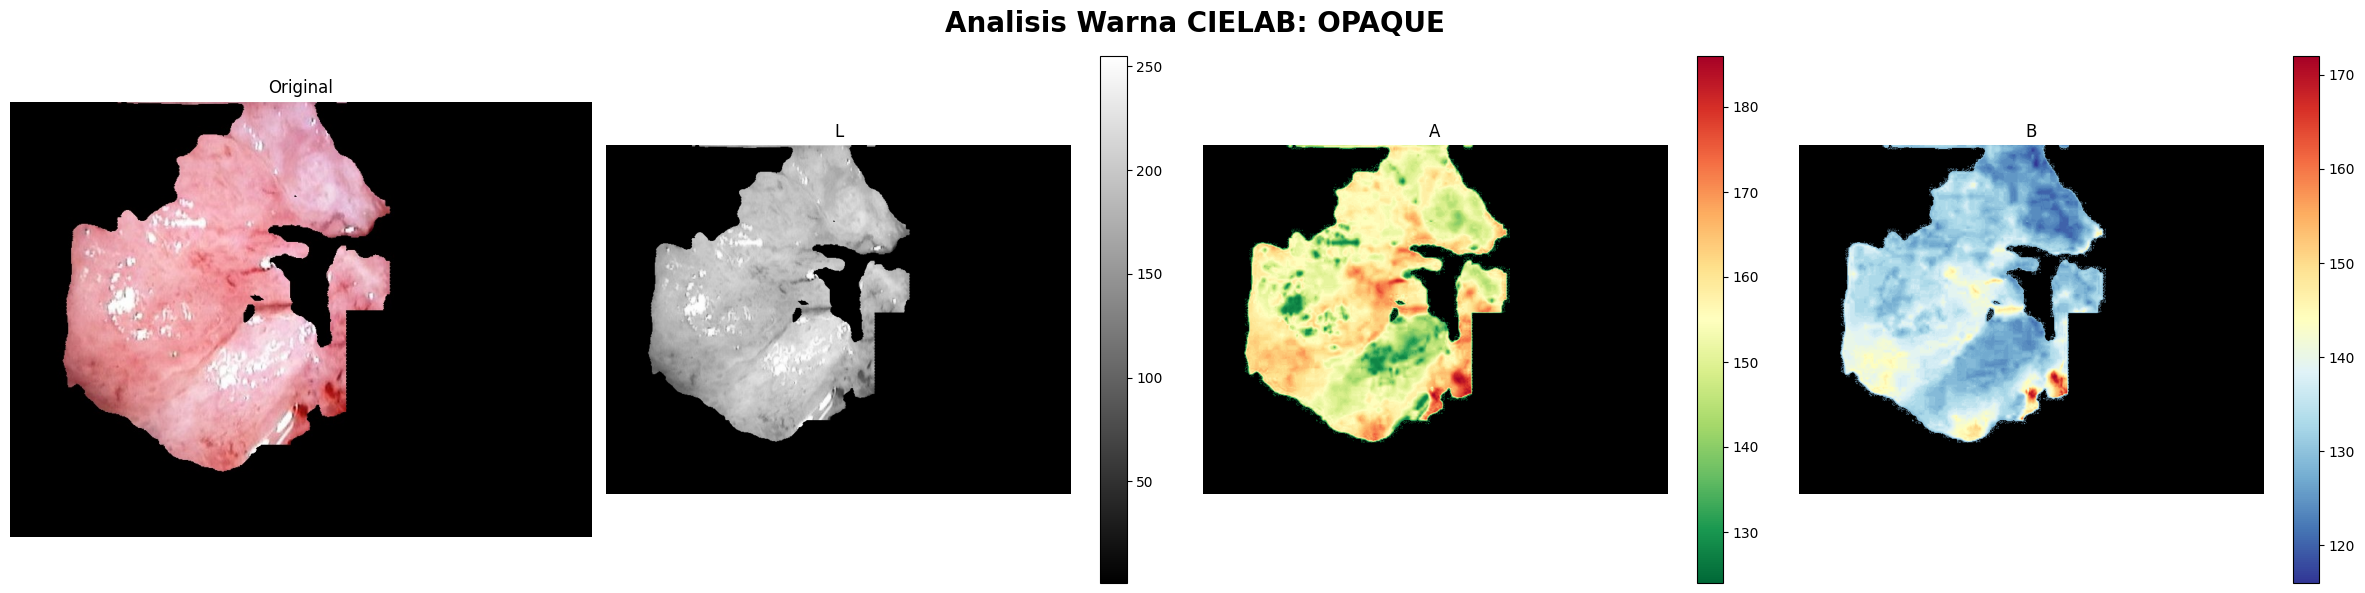

 Sample image: /content/drive/MyDrive/cimed/segmen/train/transparent/Case 022/AAIQ2.jpg


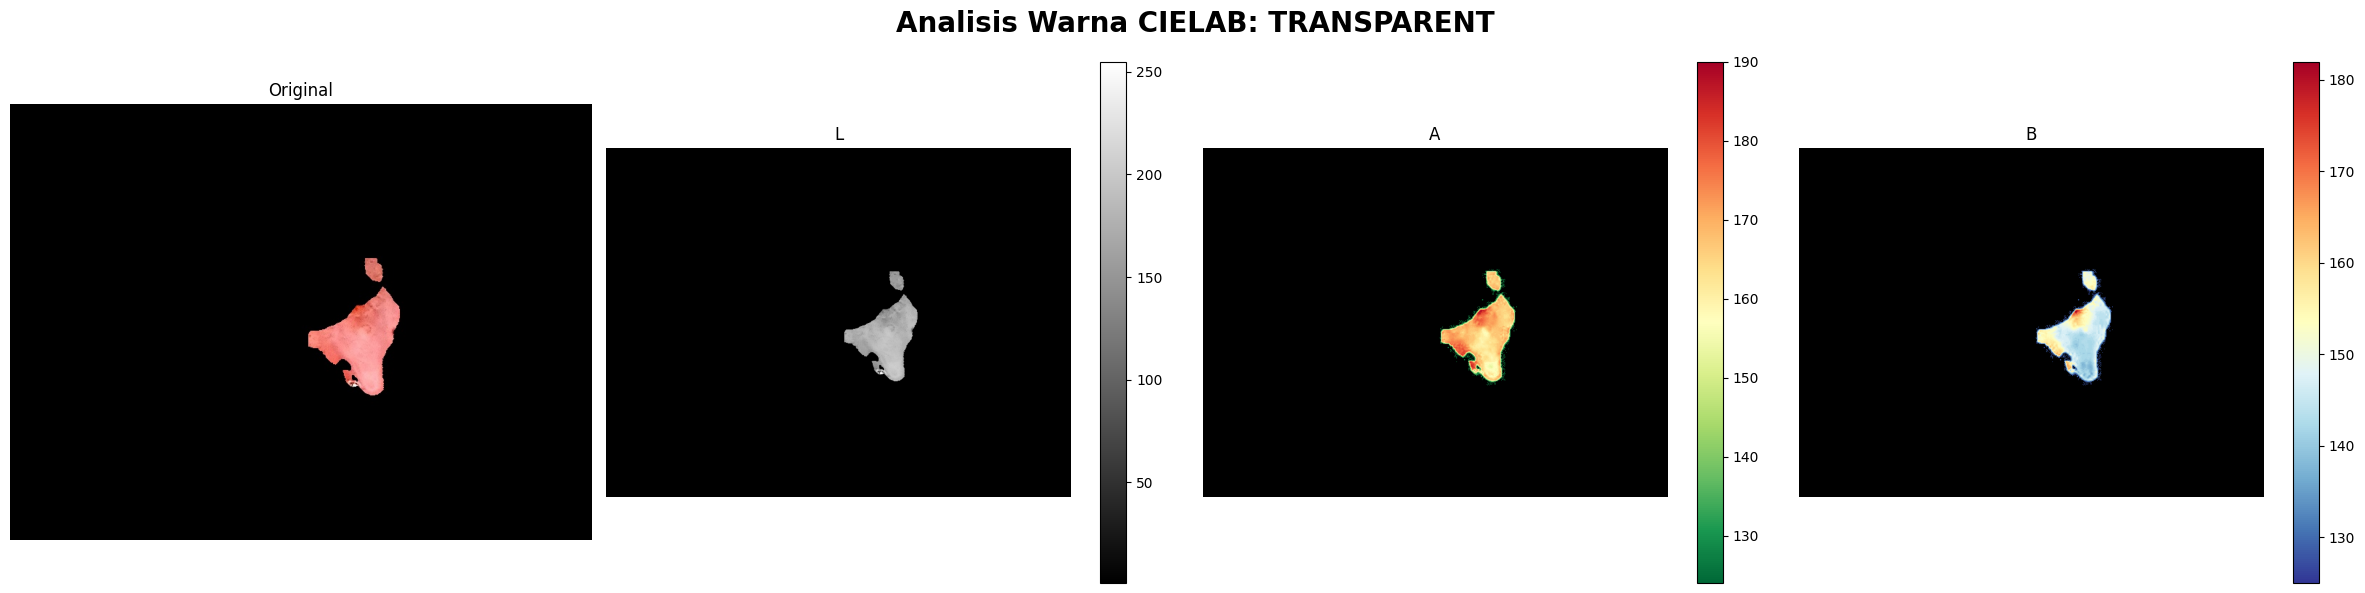

In [17]:
# Menampilkan pada data Train
categories = ['milky', 'opaque', 'transparent']
base_dir = '/content/drive/MyDrive/cimed/segmen/train'

for category in categories:
    sample_dir = os.path.join(base_dir, category)

    # Ambil semua gambar dari kategori tersebut
    all_images = get_all_images_from_category(sample_dir)

    if len(all_images) > 0:
        sample_path = random.choice(all_images)
        print(" Sample image:", sample_path)

        visualize_cielab(
            image_path=sample_path,
            category_name=category
        )
    else:
        print(f" Tidak ada gambar ditemukan di {sample_dir}")

In [18]:
def augment_image_and_mask(img, mask):
    """Augmentasi: flip horizontal dan vertical"""
    augmented_imgs = []
    augmented_masks = []

    # Flip Horizontal
    augmented_imgs.append(cv2.flip(img, 1))
    augmented_masks.append(cv2.flip(mask, 1))

    # Flip Vertical
    augmented_imgs.append(cv2.flip(img, 0))
    augmented_masks.append(cv2.flip(mask, 0))

    return augmented_imgs, augmented_masks

In [19]:
def extract_features(base_path, split_name):
    """
    Ekstraksi fitur dengan augmentasi untuk SEMUA kelas di TRAIN
    """
    feature_list = []
    CATEGORIES = ['milky', 'opaque', 'transparent']

    split_path = os.path.join(base_path, split_name)

    print(f"\n{'='*60}")
    print(f" Memproses: {split_name.upper()}")
    print(f"{'='*60}")

    for category in CATEGORIES:
        category_path = os.path.join(split_path, category)

        if not os.path.exists(category_path):
            print(f"  {category}: Directory tidak ditemukan, skipping...")
            continue

        all_image_paths = get_all_images_from_category(category_path)

        if len(all_image_paths) == 0:
            print(f" {category}: Tidak ada gambar ditemukan")
            continue

        original_count = 0
        augmented_count = 0

        print(f"\n Processing: {category}")
        print(f"   Total gambar: {len(all_image_paths)}")

        for img_path in tqdm(all_image_paths, desc=f"   {category}", leave=False):
            img_bgr = cv2.imread(img_path)
            if img_bgr is None:
                continue

            # Preprocessing
            img_wb = apply_white_balance(img_bgr)
            img_rgb = cv2.cvtColor(img_wb, cv2.COLOR_BGR2RGB)
            mask_orig = segment(img_rgb)

            # EKSTRAK FITUR GAMBAR ORIGINAL
            features = _extract_image_features(img_rgb, mask_orig)
            if features:
                features['label'] = LABEL_MAP[category]
                features['category_name'] = category
                features['split'] = split_name
                features['augmented'] = False
                feature_list.append(features)
                original_count += 1

            # AUGMENTASI HANYA UNTUK TRAIN
            if split_name == 'train':
                aug_imgs, aug_masks = augment_image_and_mask(img_rgb, mask_orig)

                for idx, (aug_img, aug_mask) in enumerate(zip(aug_imgs, aug_masks)):
                    aug_features = _extract_image_features(aug_img, aug_mask)
                    if aug_features:
                        aug_features['label'] = LABEL_MAP[category]
                        aug_features['category_name'] = category
                        aug_features['split'] = split_name
                        aug_features['augmented'] = True
                        feature_list.append(aug_features)
                        augmented_count += 1

        print(f"  Original : {original_count}")
        if split_name == 'train':
            print(f"  Augmented: {augmented_count}")
            print(f"  Total    : {original_count + augmented_count} (x{(original_count + augmented_count) / original_count:.1f})")
        else:
            print(f"  Total    : {original_count}")

    return pd.DataFrame(feature_list)

In [21]:
import cv2
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

def extract_features(base_path, split_name):
    """
    Extracts features from images in the specified split ('train' or 'test').
    Applies augmentation ONLY if split_name is 'train' and category is 'milky'.
    Augmentation Factor = 3 (Original + Flip Horizontal + Flip Vertical).
    """
    categories = ['milky', 'opaque', 'transparent']
    label_map  = {'milky': 0, 'opaque': 1, 'transparent': 2}
    data = []

    print(f"\nProcessing {split_name.upper()} set...")

    for category in categories:
        folder_path = os.path.join(base_path, split_name, category)
        if not os.path.exists(folder_path):
            continue

        # Get list of case folders
        case_folders = [
            f for f in os.listdir(folder_path)
            if os.path.isdir(os.path.join(folder_path, f))
        ]

        for case in tqdm(case_folders, desc=f"Loading {category}"):
            case_path = os.path.join(folder_path, case)

            # Find image files
            images = [
                f for f in os.listdir(case_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]

            for img_name in images:
                img_path = os.path.join(case_path, img_name)
                img_bgr = cv2.imread(img_path)
                if img_bgr is None:
                    continue

                # Preprocessing: Apply white balance and convert to RGB
                img_wb = apply_white_balance(img_bgr)
                img_rgb = cv2.cvtColor(img_wb, cv2.COLOR_BGR2RGB)

                # Segmentation: Create mask (using similar logic as visualize_cielab)
                gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                _, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

                # List of images to process (start with original)
                images_to_process = [(img_rgb, mask)]

                # --- AUGMENTATION LOGIC ---
                # Only augment if TRAIN set and MILKY category
                if split_name == 'train' and category == 'milky':
                    # The augment_image_and_mask function from cell W0KPIht0i4qz
                    # takes img_rgb and mask and returns augmented_imgs, augmented_masks
                    aug_imgs, aug_masks = augment_image_and_mask(img_rgb, mask)
                    images_to_process.extend(zip(aug_imgs, aug_masks))

                # Extract features for all images (original + augmented)
                for current_img, current_mask in images_to_process:
                    # Call the existing _extract_image_features function
                    feats = _extract_image_features(current_img, current_mask)
                    if feats: # Only append if feature extraction was successful
                        feats['label'] = label_map[category]
                        feats['category_name'] = category
                        data.append(feats)

    return pd.DataFrame(data)

# --- EKSEKUSI ---
# Ekstraksi Train (dengan augmentasi milky x3)
df_train = extract_features(base_path, 'train')

# Ekstraksi Test (tanpa augmentasi)
df_test = extract_features(base_path, 'test')

print("\nTrain Data Shape:", df_train.shape)
print("Train Data Counts:\n", df_train['category_name'].value_counts())
print("\nTest Data Shape :", df_test.shape)



Processing TRAIN set...


Loading transparent: 100%|██████████| 40/40 [00:43<00:00,  1.09s/it]



Processing TEST set...


Loading transparent: 100%|██████████| 14/14 [00:13<00:00,  1.04it/s]


Train Data Shape: (232, 31)
Train Data Counts:
 category_name
milky          93
opaque         85
transparent    54
Name: count, dtype: int64

Test Data Shape : (47, 31)


In [22]:
print("\nTrain Data Shape:", df_train.shape)
print("Train Data Counts:\n", df_train['category_name'].value_counts())
print("\nTest Data Shape :", df_test.shape)
print("Train Data Counts:\n", df_test['category_name'].value_counts())


Train Data Shape: (232, 31)
Train Data Counts:
 category_name
milky          93
opaque         85
transparent    54
Name: count, dtype: int64

Test Data Shape : (47, 31)
Train Data Counts:
 category_name
opaque         22
transparent    19
milky           6
Name: count, dtype: int64


In [23]:
print(df_train.columns)
print(len(df_train.columns))

Index(['L_mean', 'a_mean', 'b_mean', 'L_std', 'a_std', 'b_std', 'Chroma_mean',
       'Chroma_std', 'Chroma_max', 'Chroma_min', 'Hue_mean', 'Hue_std',
       'Hue_circular_mean', 'Hue_concentration', 'Light_dominance',
       'Red_dominance', 'Yellow_dominance', 'L_p25', 'L_p50', 'L_p75', 'a_p25',
       'a_p50', 'a_p75', 'b_p25', 'b_p50', 'b_p75', 'Lab_contrast',
       'Chroma_contrast', 'ab_distance', 'label', 'category_name'],
      dtype='object')
31


In [24]:
print("\n=== SELURUH OUTPUT EKSTRAKSI CIELAB (TRAIN) ===")
print(df_train.to_string(index=False))

print("\n=== SELURUH OUTPUT EKSTRAKSI CIELAB (TEST) ===")
print(df_test.to_string(index=False))


=== SELURUH OUTPUT EKSTRAKSI CIELAB (TRAIN) ===
    L_mean     a_mean     b_mean     L_std     a_std     b_std  Chroma_mean  Chroma_std  Chroma_max  Chroma_min  Hue_mean  Hue_std  Hue_circular_mean  Hue_concentration  Light_dominance  Red_dominance  Yellow_dominance  L_p25  L_p50  L_p75  a_p25  a_p50  a_p75  b_p25  b_p50  b_p75  Lab_contrast  Chroma_contrast  ab_distance  label category_name
201.770233 128.818175 127.874107 61.413678  9.120116  3.970530     8.291284    5.556950   37.363083         0.0 -0.260939 1.937360          -1.439414           0.167685         0.916537       0.496849          0.342291  201.0  221.0  234.0  122.0  128.0 134.00  125.0  127.0  129.0      0.304374         0.670216     9.946809      0         milky
201.770233 128.818175 127.874107 61.413678  9.120116  3.970530     8.291284    5.556950   37.363083         0.0 -0.260939 1.937360          -1.439414           0.167685         0.916537       0.496849          0.342291  201.0  221.0  234.0  122.0  128.0 134

#MODEL

In [25]:
feature_cols = [
       'L_mean', 'a_mean', 'b_mean', 'L_std', 'a_std', 'b_std', 'Chroma_mean',
       'Chroma_std', 'Chroma_max', 'Chroma_min', 'Hue_mean', 'Hue_std',
       'Hue_circular_mean', 'Hue_concentration', 'Light_dominance',
       'Red_dominance', 'Yellow_dominance', 'L_p25', 'L_p50', 'L_p75', 'a_p25',
       'a_p50', 'a_p75', 'b_p25', 'b_p50', 'b_p75', 'Lab_contrast',
       'Chroma_contrast', 'ab_distance'
]

In [54]:
feature_cols = [col for col in df_train.columns if col not in ['label', 'category_name', 'filename']]

print(f"Total Fitur yang dipakai: {len(feature_cols)}")
print("Nama Fitur:", feature_cols)

X_train_final = df_train[feature_cols]
y_train_final = df_train['label']

# Lakukan hal yang sama untuk Test
X_test_final = df_test[feature_cols]

Total Fitur yang dipakai: 29
Nama Fitur: ['L_mean', 'a_mean', 'b_mean', 'L_std', 'a_std', 'b_std', 'Chroma_mean', 'Chroma_std', 'Chroma_max', 'Chroma_min', 'Hue_mean', 'Hue_std', 'Hue_circular_mean', 'Hue_concentration', 'Light_dominance', 'Red_dominance', 'Yellow_dominance', 'L_p25', 'L_p50', 'L_p75', 'a_p25', 'a_p50', 'a_p75', 'b_p25', 'b_p50', 'b_p75', 'Lab_contrast', 'Chroma_contrast', 'ab_distance']


In [74]:
def _extract_image_features_complete(image_rgb, mask=None):
    # Jika tidak ada mask, pakai seluruh gambar
    if mask is None:
        mask = np.ones(image_rgb.shape[:2], dtype=np.uint8) * 255

    binary_mask = mask > 0
    if np.sum(binary_mask) < 10: return None # Skip jika mask kosong

    features = {}

    # Konversi ke LAB
    img_lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    L, a, b = cv2.split(img_lab)

    # Ambil pixel di area mask
    L_pix = L[binary_mask].astype(np.float64)
    a_pix = a[binary_mask].astype(np.float64)
    b_pix = b[binary_mask].astype(np.float64)

    # --- BASIC STATISTICS (6 Fitur) ---
    features['L_mean'] = np.mean(L_pix); features['L_std'] = np.std(L_pix)
    features['a_mean'] = np.mean(a_pix); features['a_std'] = np.std(a_pix)
    features['b_mean'] = np.mean(b_pix); features['b_std'] = np.std(b_pix)

    # --- CHROMA & HUE (8 Fitur) ---
    chroma = np.sqrt((a_pix - 128)**2 + (b_pix - 128)**2)
    features['Chroma_mean'] = np.mean(chroma)
    features['Chroma_std']  = np.std(chroma)
    features['Chroma_max']  = np.max(chroma)
    features['Chroma_min']  = np.min(chroma)

    hue = np.arctan2(b_pix - 128, a_pix - 128)
    features['Hue_mean'] = np.mean(hue)
    features['Hue_std']  = np.std(hue)
    features['Hue_circular_mean'] = np.arctan2(np.mean(np.sin(hue)), np.mean(np.cos(hue)))
    features['Hue_concentration'] = np.sqrt(np.mean(np.cos(hue))**2 + np.mean(np.sin(hue))**2)

    # --- DOMINANCE (3 Fitur) ---
    features['Light_dominance']  = np.sum(L_pix > 128) / len(L_pix)
    features['Red_dominance']    = np.sum(a_pix > 128) / len(a_pix)
    features['Yellow_dominance'] = np.sum(b_pix > 128) / len(b_pix)

    # --- PERCENTILES (9 Fitur) ---
    for p in [25, 50, 75]:
        features[f'L_p{p}'] = np.percentile(L_pix, p)
        features[f'a_p{p}'] = np.percentile(a_pix, p)
        features[f'b_p{p}'] = np.percentile(b_pix, p)

    # --- CONTRAST (3 Fitur) ---
    features['Lab_contrast'] = np.std(L_pix) / (np.mean(L_pix) + 1e-7)
    features['Chroma_contrast'] = np.std(chroma) / (np.mean(chroma) + 1e-7)
    features['ab_distance'] = np.sqrt(np.mean((a_pix - np.mean(a_pix))**2 + (b_pix - np.mean(b_pix))**2))

    return features

In [75]:
def load_data_with_29_features(base_path, split):
    data = []
    categories = ['milky', 'opaque', 'transparent']
    label_map = {'milky': 0, 'opaque': 1, 'transparent': 2}

    for cat in categories:
        folder = os.path.join(base_path, split, cat)
        if not os.path.exists(folder): continue

        for case in tqdm(os.listdir(folder), desc=f"Loading {split} {cat}"):
            case_path = os.path.join(folder, case)
            if not os.path.isdir(case_path): continue

            for f in os.listdir(case_path):
                if f.lower().endswith(('.jpg','.png')):
                    img = cv2.imread(os.path.join(case_path, f))
                    if img is None: continue
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                    # Augmentasi Milky di Train (x3)
                    imgs_proc = [img_rgb]
                    if split == 'train' and cat == 'milky':
                        imgs_proc.append(cv2.flip(img_rgb, 1))
                        imgs_proc.append(cv2.flip(img_rgb, 0))

                    for i_proc in imgs_proc:
                        # Extract 29 Fitur
                        feats = _extract_image_features_complete(i_proc) # Auto mask full
                        if feats:
                            feats['label'] = label_map[cat]
                            data.append(feats)
    return pd.DataFrame(data)

In [76]:
X = df_train[feature_cols]
y = df_train['label']

In [77]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [78]:
X_test = df_test[feature_cols]
y_test = df_test['label']

print("TRAIN FINAL :", X_train_final.shape)
print("VALIDATION  :", X_val.shape)
print("TEST        :", X_test.shape)


TRAIN FINAL : (185, 29)
VALIDATION  : (47, 29)
TEST        : (47, 29)


In [79]:
X_test = df_test[feature_cols]
y_test = df_test['label']

In [86]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Sedang mengambil ulang data dengan 29 fitur...")
df_train = load_data_with_29_features(base_path, 'train')
df_test  = load_data_with_29_features(base_path, 'test')

# ==============================================================================
# 3. TRAINING LOGISTIC REGRESSION + PCA (SESUAI REQUEST)
# ==============================================================================
# Definisi 29 Kolom Fitur
feature_cols = [c for c in df_train.columns if c not in ['label', 'category_name']]
print(f"\nJumlah Fitur Terdeteksi: {len(feature_cols)} (Harus 29)")

# Prepare data for splitting
X_full_train = df_train[feature_cols]
y_full_train = df_train['label']

# Perform train-validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_full_train, y_full_train,
    test_size=0.20,
    random_state=42,
    stratify=y_full_train
)

# Prepare test data
X_test = df_test[feature_cols]
y_test = df_test['label']

print("\nTRAIN FINAL :", X_train_final.shape)
print("VALIDATION  :", X_val.shape)
print("TEST        :", X_test.shape)


# Model Pipeline (Logistic Regression + PCA)
# SAYA UBAH C=1.0 (Bukan 0.05) AGAR HASIL LEBIH BAGUS
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=12, random_state=42)), # Sekarang aman karena fitur 29
    ('clf', LogisticRegression(
        solver='saga',
        penalty='elasticnet',
        l1_ratio=0.7,
        C=1.0,  # <-- Diperkuat biar gak underfit
        multi_class='multinomial',
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

print("\nMelatih Model...")
model_pipeline.fit(X_train_final, y_train_final) # Fit on the actual training split


Sedang mengambil ulang data dengan 29 fitur...


Loading test transparent: 100%|██████████| 14/14 [00:02<00:00,  6.51it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Jumlah Fitur Terdeteksi: 29 (Harus 29)

TRAIN FINAL : (185, 29)
VALIDATION  : (47, 29)
TEST        : (47, 29)

Melatih Model...


Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=12, random_state=42)),
                ('clf',
                 LogisticRegression(class_weight='balanced', l1_ratio=0.7,
                                    max_iter=5000, multi_class='multinomial',
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])

### Evaluasi model

In [87]:
def calculate_specificity(y_true, y_pred, labels):
    """Menghitung specificity untuk setiap kelas"""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    specificity = []

    for i in range(len(labels)):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity.append(spec)

    return specificity

In [88]:
def print_evaluation_metrics(y_true, y_pred, dataset_name="", category_names=None):
    from sklearn.metrics import accuracy_score

    labels = [0, 1, 2] # Define labels here

    # Recall per kelas
    recall = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    # Specificity per kelas
    specificity = calculate_specificity(y_true, y_pred, labels)
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    # Hitung support (jumlah sampel per kelas)
    support = [np.sum(y_true == label) for label in labels]
    # Hitung macro & weighted average
    macro_recall = np.mean(recall)
    macro_specificity = np.mean(specificity)
    weighted_recall = np.average(recall, weights=support)
    weighted_specificity = np.average(specificity, weights=support)

    print(f"\nClassification Report {dataset_name}:")
    print(f"{'':>15} {'recall':<12} {'accuracy':<12} {'specificity':<12} {'support':<12}")
    print()

    # Print per kelas
    for i, cat_name in enumerate(category_names):
        print(f"{cat_name:>15} {recall[i]:>8.2f}      {accuracy:>8.2f}      {specificity[i]:>8.2f}      {support[i]:>8}")

    print()

    # Print macro average
    print(f"{'macro avg':>15} {macro_recall:>8.2f}      {accuracy:>8.2f}      {macro_specificity:>8.2f}      {sum(support):>8}")
    # Print weighted average
    print(f"{'weighted avg':>15} {weighted_recall:>8.2f}      {accuracy:>8.2f}      {weighted_specificity:>8.2f}      {sum(support):>8}")
    print()

In [90]:
from sklearn.metrics import recall_score

# model_pipeline.fit(X_train_final, y_train_final) # This fit is now done in cell gzPk28YX9m5_

y_train_pred_pca = model_pipeline.predict(X_train_final)
y_val_pred_pca = model_pipeline.predict(X_val)
y_test_pred_pca = model_pipeline.predict(X_test)

# Using the actual_categories list for correct labels
actual_categories = ['milky', 'opaque', 'transparent']

print_evaluation_metrics(y_train_final, y_train_pred_pca, "TRAIN", category_names=actual_categories)
print_evaluation_metrics(y_val, y_val_pred_pca, "VALIDATION", category_names=actual_categories)
print_evaluation_metrics(y_test, y_test_pred_pca, "TEST", category_names=actual_categories)



Classification Report TRAIN:
                recall       accuracy     specificity  support     

          milky     0.58          0.56          0.73            74
         opaque     0.47          0.56          0.86            68
    transparent     0.65          0.56          0.75            43

      macro avg     0.57          0.56          0.78           185
   weighted avg     0.56          0.56          0.78           185


Classification Report VALIDATION:
                recall       accuracy     specificity  support     

          milky     0.74          0.55          0.68            19
         opaque     0.24          0.55          0.87            17
    transparent     0.73          0.55          0.78            11

      macro avg     0.57          0.55          0.77            47
   weighted avg     0.55          0.55          0.77            47


Classification Report TEST:
                recall       accuracy     specificity  support     

          milky     0.67 

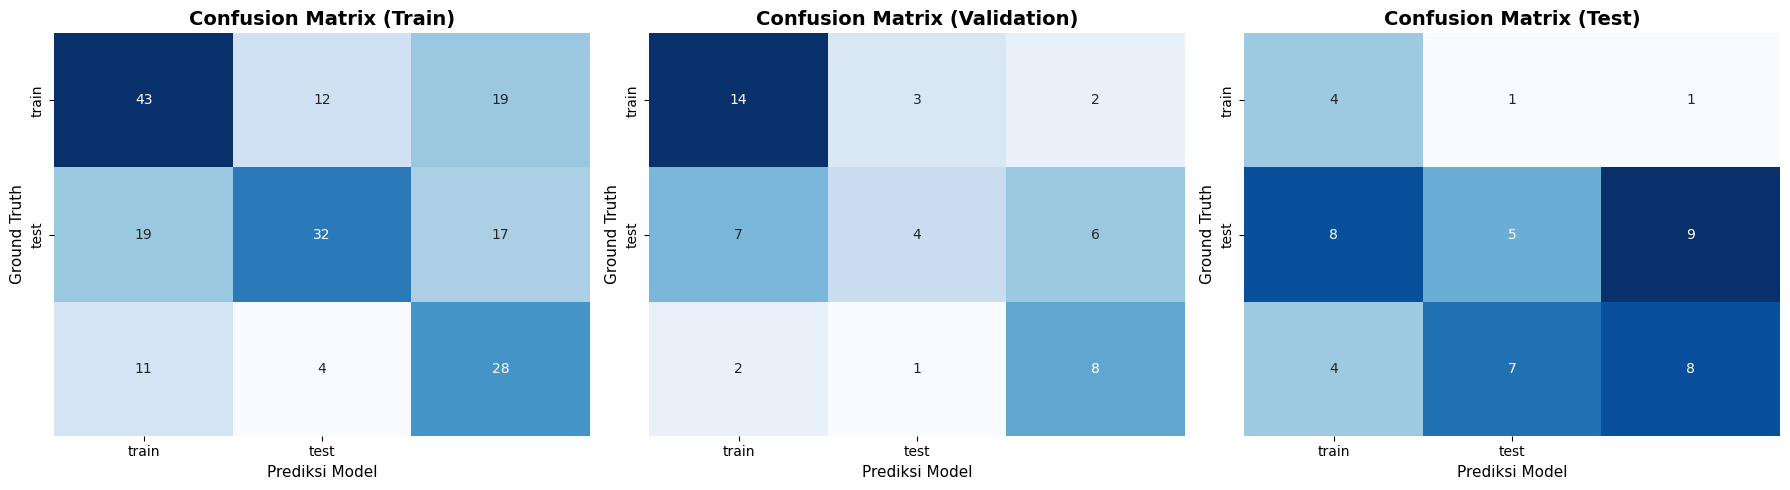

In [91]:
datasets = [
    (y_train_final, y_train_pred_pca, 'Train'),
    (y_val, y_val_pred_pca, 'Validation'),
    (y_test, y_test_pred_pca, 'Test')
]

# Buat kanvas dengan 1 baris dan 3 kolom
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (y_true, y_pred, title) in enumerate(datasets):
    # Hitung Confusion Matrix untuk set data saat ini
    cm = confusion_matrix(y_true, y_pred)

    # Plot di sumbu (axis) yang sesuai (axes[i])
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CATEGORIES,
                yticklabels=CATEGORIES,
                cmap='Blues', cbar=False, ax=axes[i]) # cbar=False biar tidak penuh

    # Atur judul dan label
    axes[i].set_title(f"Confusion Matrix ({title})", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Prediksi Model", fontsize=11)
    axes[i].set_ylabel("Ground Truth", fontsize=11)

plt.tight_layout()
plt.show()

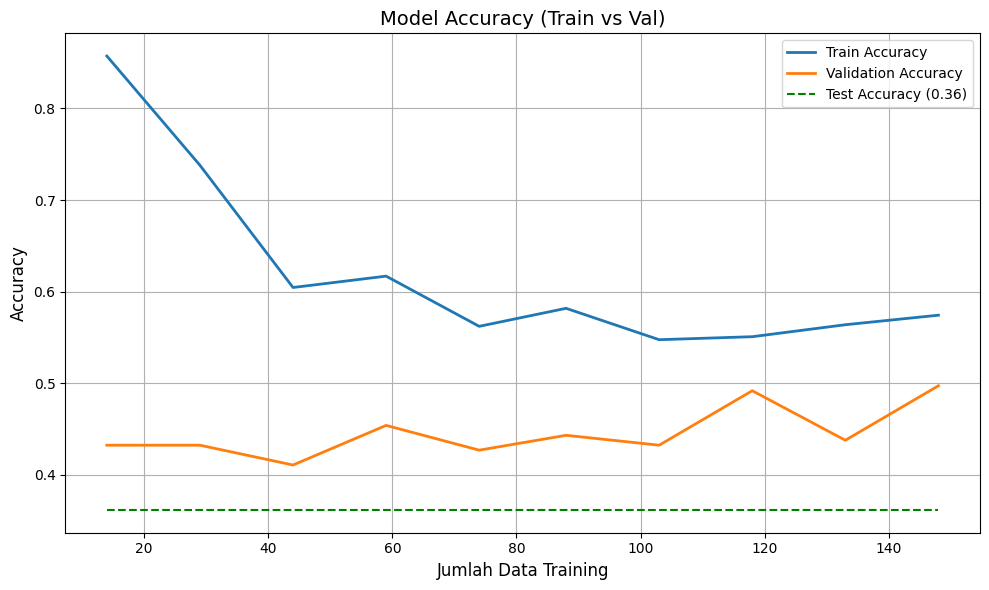

In [96]:
# HITUNG LEARNING CURVE

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_pipeline,
    X=X_train_final,
    y=y_train_final,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Hitung Rata-rata saja (Standar Deviasi tidak dipakai untuk plot garis simpel)
train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
test_acc = accuracy_score(y_test, y_test_pred_pca)


# PLOT GRAFIK
plt.figure(figsize=(10, 6))

# Plot Garis Train (Biru)
plt.plot(train_sizes, train_mean, label='Train Accuracy',
         color='tab:blue', linewidth=2)

# Plot Garis Validation (Oranye/Merah)
plt.plot(train_sizes, val_mean, label='Validation Accuracy',
         color='tab:orange', linewidth=2)

# (Opsional) Garis Test Accuracy sebagai benchmark
plt.hlines(test_acc, xmin=train_sizes[0], xmax=train_sizes[-1],
           colors='green', linestyles='--', label=f'Test Accuracy ({test_acc:.2f})')

# Judul & Label
plt.title('Model Accuracy (Train vs Val)', fontsize=14)
plt.xlabel('Jumlah Data Training', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()


## **ANALISIS KEPERCAYAAN & ERROR**


  ANALISIS TRUST (Threshold = 60.0%))
1. TOTAL DATA TEST         : 47 sampel
------------------------------------------------------------
2. JUMLAH DATA TRUSTED     : 10 (21.3%)
   -> Akurasi di kel. ini  : 40.00% (Prediksi yang 'yakin' biasanya lebih benar)
------------------------------------------------------------
3. JUMLAH DATA UNRELIABLE  : 37 (78.7%)
   -> Akurasi di kel. ini  : 35.14% (Prediksi yang 'ragu' sering salah)
------------------------------------------------------------
4. GLOBAL ACCURACY (Awal)  : 36.17%
5. FATAL ERROR             : 2 Pasien


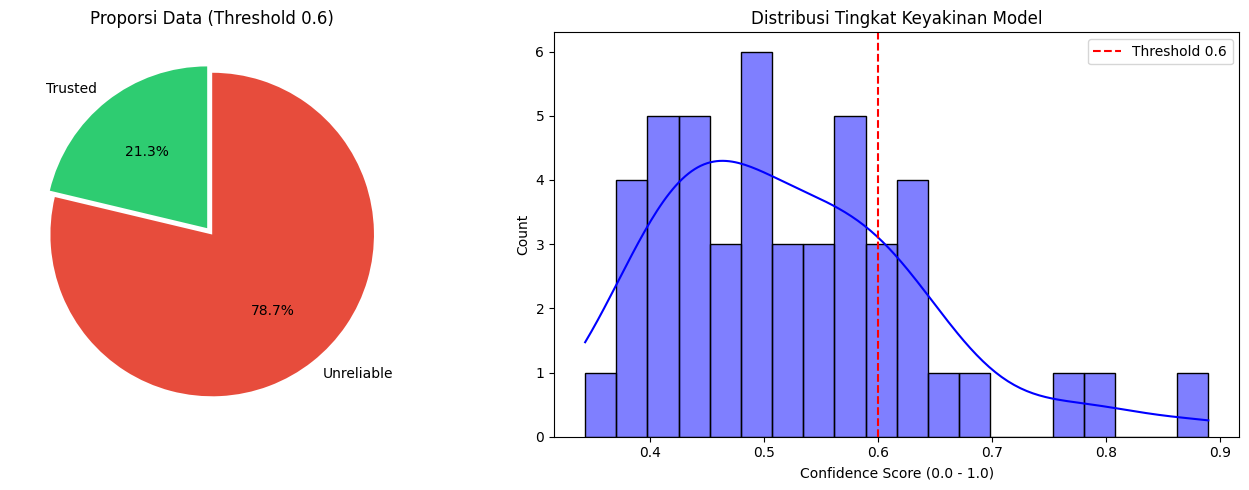

In [97]:
def analyze_trust_detailed(model, X, y_true, categories):
    # 1. Ambil Probabilitas & Prediksi
    probs = model.predict_proba(X)
    preds = model.predict(X)
    confidence = np.max(probs, axis=1)

    # 2. Setup Threshold
    TRUST_THRESHOLD = 0.60

    results = []
    fatal_errors = 0

    for i in range(len(y_true)):
        true_lbl = y_true.iloc[i]
        pred_lbl = preds[i]
        conf_score = confidence[i]

        # Status
        is_trusted = conf_score >= TRUST_THRESHOLD
        status = " Trusted" if is_trusted else " Unreliable"

        # Cek Kebenaran Prediksi
        is_correct = true_lbl == pred_lbl

        # Deteksi Fatal Error (High Risk -> Normal/Opaque)
        is_fatal = False
        if true_lbl == 0 and pred_lbl != 0:
            is_fatal = True
            fatal_errors += 1

        results.append({
            'Ground Truth': categories[true_lbl],
            'Prediksi': categories[pred_lbl],
            'Confidence': conf_score,
            'Status': status,
            'Is Correct': is_correct,
            'Is Fatal': is_fatal
        })

    df = pd.DataFrame(results)

    # --- HITUNG JUMLAH (COUNTING) ---
    total_data = len(df)
    trusted_data = df[df['Status'] == " Trusted"]
    unreliable_data = df[df['Status'] == " Unreliable"]

    n_trusted = len(trusted_data)
    n_unreliable = len(unreliable_data)

    # Hitung Akurasi pada masing-masing kelompok
    acc_trusted = trusted_data['Is Correct'].mean() if n_trusted > 0 else 0
    acc_unreliable = unreliable_data['Is Correct'].mean() if n_unreliable > 0 else 0
    acc_global = df['Is Correct'].mean()

    # --- TAMPILKAN LAPORAN ---
    print("\n" + "="*60)
    print(f"  ANALISIS TRUST (Threshold = {TRUST_THRESHOLD*100}%))")
    print("="*60)
    print(f"1. TOTAL DATA TEST         : {total_data} sampel")
    print("-" * 60)
    print(f"2. JUMLAH DATA TRUSTED     : {n_trusted} ({n_trusted/total_data*100:.1f}%)")
    print(f"   -> Akurasi di kel. ini  : {acc_trusted*100:.2f}% (Prediksi yang 'yakin' biasanya lebih benar)")
    print("-" * 60)
    print(f"3. JUMLAH DATA UNRELIABLE  : {n_unreliable} ({n_unreliable/total_data*100:.1f}%)")
    print(f"   -> Akurasi di kel. ini  : {acc_unreliable*100:.2f}% (Prediksi yang 'ragu' sering salah)")
    print("-" * 60)
    print(f"4. GLOBAL ACCURACY (Awal)  : {acc_global*100:.2f}%")
    print(f"5. FATAL ERROR             : {fatal_errors} Pasien")
    print("="*60)

    # --- VISUALISASI ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Grafik 1: Pie Chart Proporsi Trusted vs Unreliable
    axes[0].pie([n_trusted, n_unreliable], labels=['Trusted', 'Unreliable'],
                autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0))
    axes[0].set_title(f'Proporsi Data (Threshold {TRUST_THRESHOLD})')

    # Grafik 2: Histogram Confidence Score
    sns.histplot(df['Confidence'], bins=20, kde=True, ax=axes[1], color='blue')
    axes[1].axvline(TRUST_THRESHOLD, color='red', linestyle='--', label=f'Threshold {TRUST_THRESHOLD}')
    axes[1].set_title('Distribusi Tingkat Keyakinan Model')
    axes[1].set_xlabel('Confidence Score (0.0 - 1.0)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return df

# JALANKAN FUNGSI
# Use actual_categories instead of the incorrect CATEGORIES
df_result = analyze_trust_detailed(model_pipeline, X_test, y_test, actual_categories)



=== Sampel Hasil Prediksi (10 Acak) ===
                 Ground Truth Prediksi Visual               Diagnosa CIN  \
27      CIN 2 (Moderate Risk)           milky          CIN 3 (High Risk)   
39  CIN 1 / Normal (Low Risk)           milky          CIN 3 (High Risk)   
26      CIN 2 (Moderate Risk)           milky          CIN 3 (High Risk)   
43  CIN 1 / Normal (Low Risk)     transparent  CIN 1 / Normal (Low Risk)   
24      CIN 2 (Moderate Risk)          opaque      CIN 2 (Moderate Risk)   
36  CIN 1 / Normal (Low Risk)          opaque      CIN 2 (Moderate Risk)   
12      CIN 2 (Moderate Risk)           milky          CIN 3 (High Risk)   
19      CIN 2 (Moderate Risk)     transparent  CIN 1 / Normal (Low Risk)   
4           CIN 3 (High Risk)           milky          CIN 3 (High Risk)   
25      CIN 2 (Moderate Risk)           milky          CIN 3 (High Risk)   

   Confidence  
27      38.6%  
39      36.7%  
26      39.2%  
43      38.9%  
24      40.1%  
36      37.0%  
12      36

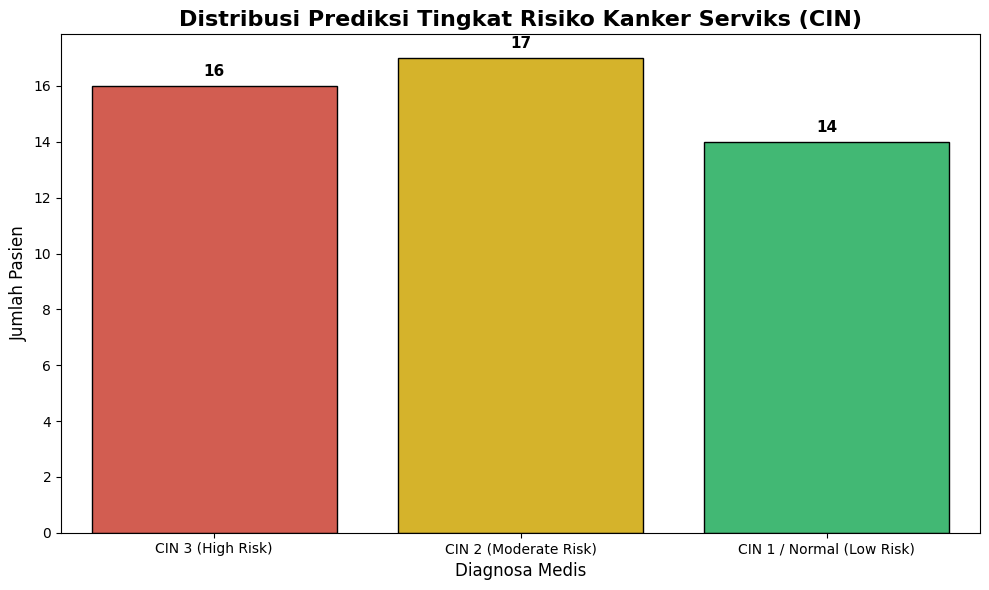

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. SETUP MAPPING LABEL & DIAGNOSA
# ==============================================================================
# Definisi Mapping Label
CATEGORIES = ['milky', 'opaque', 'transparent']
CIN_MAP = {
    0: "CIN 3 (High Risk)",       # Milky
    1: "CIN 2 (Moderate Risk)",   # Opaque
    2: "CIN 1 / Normal (Low Risk)" # Transparent
}

# Warna untuk grafik
palette_colors = {
    'CIN 3 (High Risk)': '#e74c3c',       # Merah
    'CIN 2 (Moderate Risk)': '#f1c40f',   # Kuning
    'CIN 1 / Normal (Low Risk)': '#2ecc71' # Hijau
}

# ==============================================================================
# 2. GENERATE PREDIKSI & DATAFRAME LAPORAN
# ==============================================================================
# Pastikan kita menggunakan data TEST untuk laporan akhir
# model_pca.predict_proba akan menghasilkan probabilitas untuk setiap kelas
visual_prob = model_pca.predict_proba(X_test)
y_pred_final = model_pca.predict(X_test)

final_report = []

# Loop untuk setiap data di Test Set
# Kita ambil label asli (y_test) dan label prediksi (y_pred_final)
# Note: y_test bisa berupa pandas Series, jadi kita akses via .iloc atau list
y_test_list = y_test.tolist() if isinstance(y_test, pd.Series) else y_test

for i in range(len(y_test)):
    pred_label = y_pred_final[i]
    true_label = y_test_list[i]

    final_report.append({
        "Ground Truth": CIN_MAP[true_label],            # Diagnosa Dokter (Asli)
        "Prediksi Visual": CATEGORIES[pred_label],      # Kategori Visual (Milky/dll)
        "Diagnosa CIN": CIN_MAP[pred_label],            # Diagnosa AI
        "Confidence": f"{np.max(visual_prob[i])*100:.1f}%" # Tingkat Keyakinan AI
    })

# Buat DataFrame
df_report = pd.DataFrame(final_report)

# Tampilkan 10 Sampel Acak
print("\n=== Sampel Hasil Prediksi (10 Acak) ===")
# Menggunakan try-except untuk menghindari error jika data kurang dari 10
try:
    print(df_report.sample(10))
except ValueError:
    print(df_report) # Tampilkan semua jika data < 10

# ==============================================================================
# 3. VISUALISASI GRAFIK (COUNT PLOT)
# ==============================================================================
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_report,
    x='Diagnosa CIN',
    hue='Diagnosa CIN', # Ditambahkan untuk menghindari warning di versi Seaborn baru
    order=[
        'CIN 3 (High Risk)',
        'CIN 2 (Moderate Risk)',
        'CIN 1 / Normal (Low Risk)'
    ],
    palette=palette_colors,
    edgecolor='black',
    legend=False # Mematikan legenda karena sudah jelas di sumbu X
)

plt.title("Distribusi Prediksi Tingkat Risiko Kanker Serviks (CIN)", fontsize=16, fontweight='bold')
plt.xlabel("Diagnosa Medis", fontsize=12)
plt.ylabel("Jumlah Pasien", fontsize=12)

# Tampilkan angka jumlah di atas batang
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()